# EDA — Home Credit Default Risk

**Objetivo:** Entender la tabla principal `application_train.csv` antes de modelar.

Preguntas que queremos responder:
1. ¿Qué tan desbalanceado está el target?
2. ¿Cuántos valores faltantes hay y en qué columnas?
3. ¿Qué variables numéricas se correlacionan con el incumplimiento?
4. ¿Hay variables categóricas con poder predictivo obvio?
5. ¿Hay outliers o datos anómalos que debemos tratar?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

DATA_PATH = '../data/raw/application_train.csv'

## 1. Carga y primera inspección

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
df.head(3)

Filas: 307,511  |  Columnas: 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000,406597.500,24700.500,351000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.019,-9461,-637,-3648.000,-2120,NaN,1,1,0,1,1,0,Laborers,1.000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083,0.263,0.139,0.025,0.037,0.972,0.619,0.014,0.000,...,0.025,0.037,0.972,0.624,0.014,0.000,0.069,0.083,0.125,0.037,0.021,0.019,0.000,0.000,reg oper account,block of flats,0.015,"Stone, brick",No,2.000,2.000,2.000,2.000,-1134.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000
1,100003,0,Cash loans,F,N,N,0,270000.000,1293502.500,35698.500,1129500.000,Family,State servant,Higher education,Married,House / apartment,0.004,-16765,-1188,-1186.000,-291,NaN,1,1,0,1,1,0,Core staff,2.000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311,0.622,NaN,0.096,0.053,0.985,0.796,0.060,0.080,...,0.097,0.053,0.985,0.799,0.061,0.080,0.035,0.292,0.333,0.013,0.079,0.056,0.004,0.010,reg oper account,block of flats,0.071,Block,No,1.000,0.000,1.000,0.000,-828.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
2,100004,0,Revolving loans,M,Y,Y,0,67500.000,135000.000,6750.000,135000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010,-19046,-225,-4260.000,-2531,26.000,1,1,1,1,1,0,Laborers,1.000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.556,0.730,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,-815.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000


In [3]:
df.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

## 2. Variable objetivo — ¿Qué tan desbalanceado está el problema?

En crédito, los incumplimientos son raros. Si el dataset tiene 8% de TARGET=1,
un modelo que siempre predice 0 tiene 92% de accuracy — pero es inútil.
Por eso usamos ROC-AUC y Recall como métricas principales.

Distribución del TARGET:
         count    pct
TARGET               
0       282686 91.930
1        24825  8.070


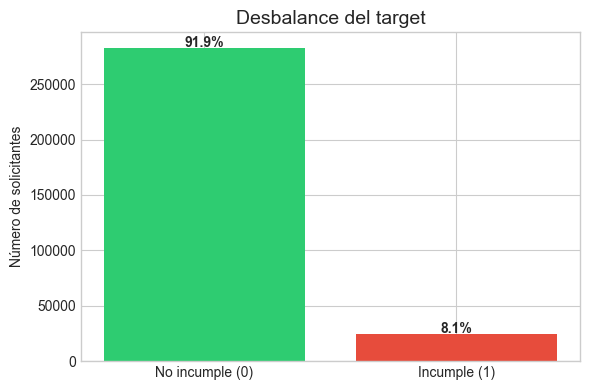

In [4]:
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print('Distribución del TARGET:')
print(pd.DataFrame({'count': target_counts, 'pct': target_pct}).round(2))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No incumple (0)', 'Incumple (1)'], target_counts, color=['#2ecc71', '#e74c3c'])
for bar, pct in zip(bars, target_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{pct:.1f}%', ha='center', fontweight='bold')
ax.set_title('Desbalance del target', fontsize=14)
ax.set_ylabel('Número de solicitantes')
plt.tight_layout()
plt.show()

## 3. Valores faltantes

Con 122 columnas, muchas tienen missings. Necesitamos saber:
- ¿Cuáles columnas tienen más del 40% de datos faltantes? (candidatas a eliminar)
- ¿Los missings son aleatorios o correlacionan con el target?

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columnas con valores faltantes: {len(missing_df)} de {df.shape[1]}')
print(f'Columnas con >40% faltantes: {(missing_df["missing_pct"] > 40).sum()}')
missing_df.head(20)

Columnas con valores faltantes: 67 de 122
Columnas con >40% faltantes: 49


,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.870
COMMONAREA_AVG,214865,69.870
COMMONAREA_MODE,214865,69.870
NONLIVINGAPARTMENTS_MEDI,213514,69.430
NONLIVINGAPARTMENTS_MODE,213514,69.430
NONLIVINGAPARTMENTS_AVG,213514,69.430
FONDKAPREMONT_MODE,210295,68.390
LIVINGAPARTMENTS_MODE,210199,68.350
LIVINGAPARTMENTS_MEDI,210199,68.350
LIVINGAPARTMENTS_AVG,210199,68.350


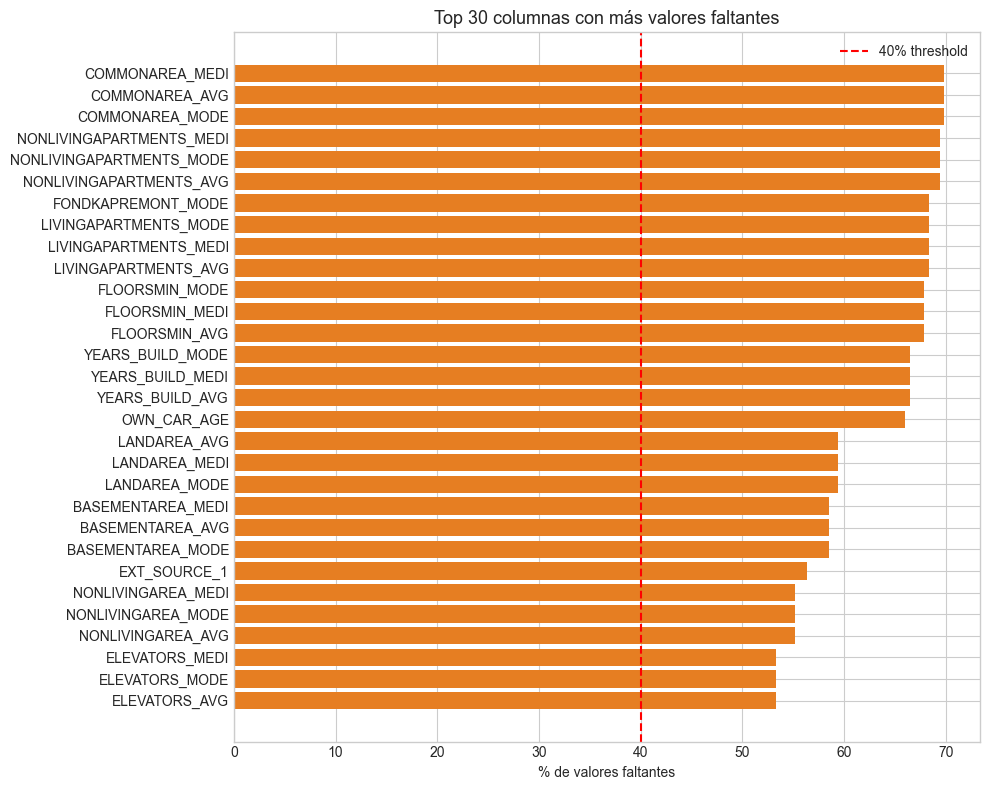

In [6]:
# Visualizar los 30 peores
top_missing = missing_df.head(30)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_missing.index[::-1], top_missing['missing_pct'][::-1], color='#e67e22')
ax.axvline(40, color='red', linestyle='--', label='40% threshold')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Top 30 columnas con más valores faltantes', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Variables numéricas — distribución y correlación con TARGET

In [7]:
# Correlación de variables numéricas con el target
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'TARGET' and c != 'SK_ID_CURR']

correlations = df[num_cols + ['TARGET']].corr()['TARGET'].drop('TARGET')
correlations = correlations.abs().sort_values(ascending=False)

print('Top 20 variables numéricas más correlacionadas con TARGET:')
print(correlations.head(20).to_string())

Top 20 variables numéricas más correlacionadas con TARGET:
EXT_SOURCE_3                  0.179
EXT_SOURCE_2                  0.160
EXT_SOURCE_1                  0.155
DAYS_BIRTH                    0.078
REGION_RATING_CLIENT_W_CITY   0.061
REGION_RATING_CLIENT          0.059
DAYS_LAST_PHONE_CHANGE        0.055
DAYS_ID_PUBLISH               0.051
REG_CITY_NOT_WORK_CITY        0.051
FLAG_EMP_PHONE                0.046
DAYS_EMPLOYED                 0.045
REG_CITY_NOT_LIVE_CITY        0.044
FLAG_DOCUMENT_3               0.044
FLOORSMAX_AVG                 0.044
FLOORSMAX_MEDI                0.044
FLOORSMAX_MODE                0.043
DAYS_REGISTRATION             0.042
AMT_GOODS_PRICE               0.040
OWN_CAR_AGE                   0.038
REGION_POPULATION_RELATIVE    0.037


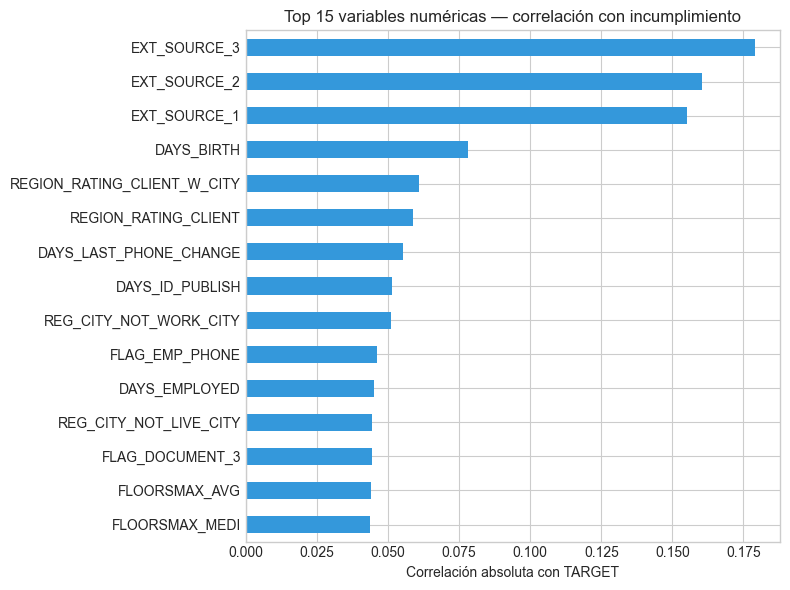

In [8]:
top_num = correlations.head(15).index.tolist()

fig, ax = plt.subplots(figsize=(8, 6))
correlations.head(15).sort_values().plot(kind='barh', ax=ax, color='#3498db')
ax.set_xlabel('Correlación absoluta con TARGET')
ax.set_title('Top 15 variables numéricas — correlación con incumplimiento', fontsize=12)
plt.tight_layout()
plt.show()

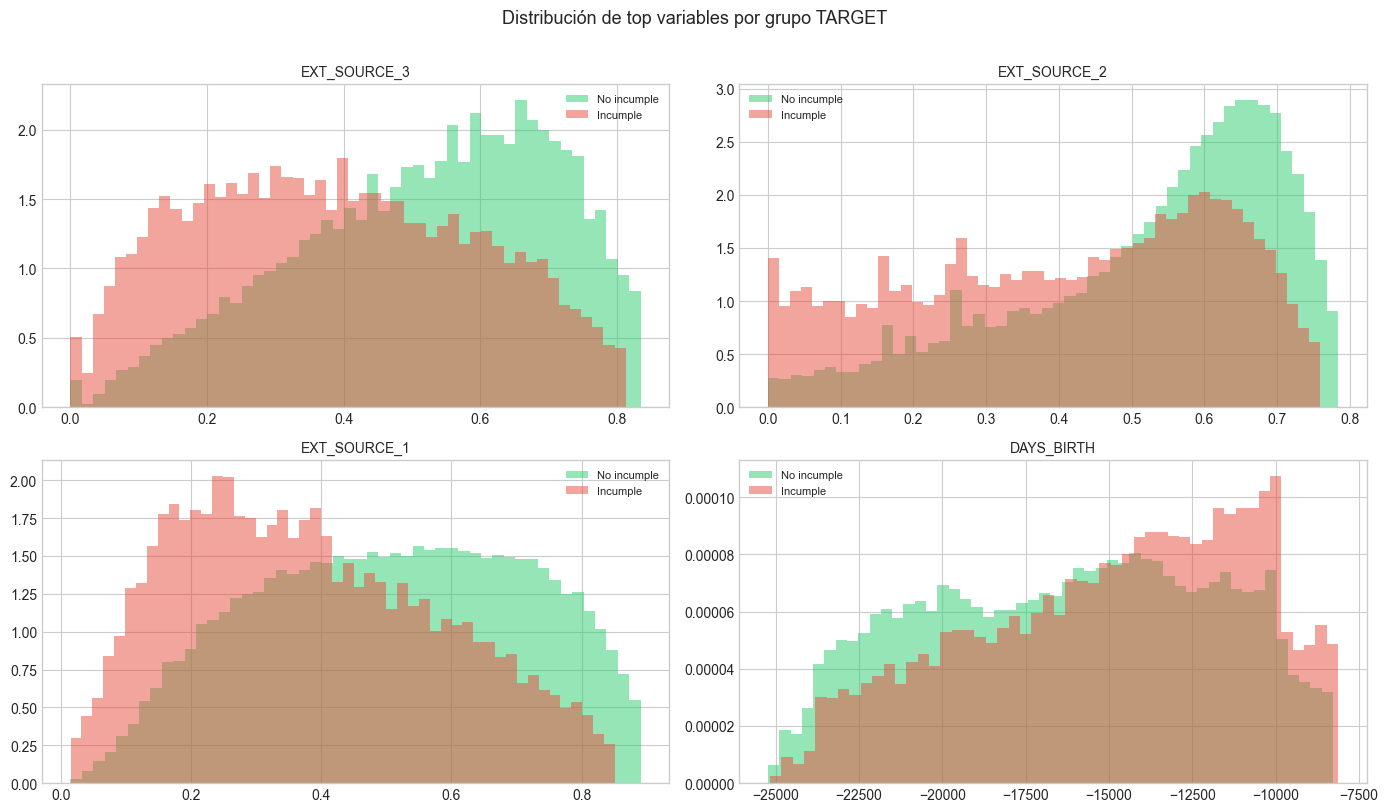

In [9]:
# Distribución de las 4 variables más importantes por grupo TARGET
top4 = correlations.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(top4):
    for target_val, label, color in [(0, 'No incumple', '#2ecc71'), (1, 'Incumple', '#e74c3c')]:
        data = df[df['TARGET'] == target_val][col].dropna()
        # Eliminar outliers extremos para visualización
        q99 = data.quantile(0.99)
        data = data[data <= q99]
        axes[i].hist(data, bins=50, alpha=0.5, label=label, color=color, density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de top variables por grupo TARGET', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Variables categóricas

In [10]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Variables categóricas: {len(cat_cols)}')
for col in cat_cols:
    print(f'  {col}: {df[col].nunique()} categorías')

Variables categóricas: 16
  NAME_CONTRACT_TYPE: 2 categorías
  CODE_GENDER: 3 categorías
  FLAG_OWN_CAR: 2 categorías
  FLAG_OWN_REALTY: 2 categorías
  NAME_TYPE_SUITE: 7 categorías
  NAME_INCOME_TYPE: 8 categorías
  NAME_EDUCATION_TYPE: 5 categorías
  NAME_FAMILY_STATUS: 6 categorías
  NAME_HOUSING_TYPE: 6 categorías
  OCCUPATION_TYPE: 18 categorías
  WEEKDAY_APPR_PROCESS_START: 7 categorías
  ORGANIZATION_TYPE: 58 categorías
  FONDKAPREMONT_MODE: 4 categorías
  HOUSETYPE_MODE: 3 categorías
  WALLSMATERIAL_MODE: 7 categorías
  EMERGENCYSTATE_MODE: 2 categorías


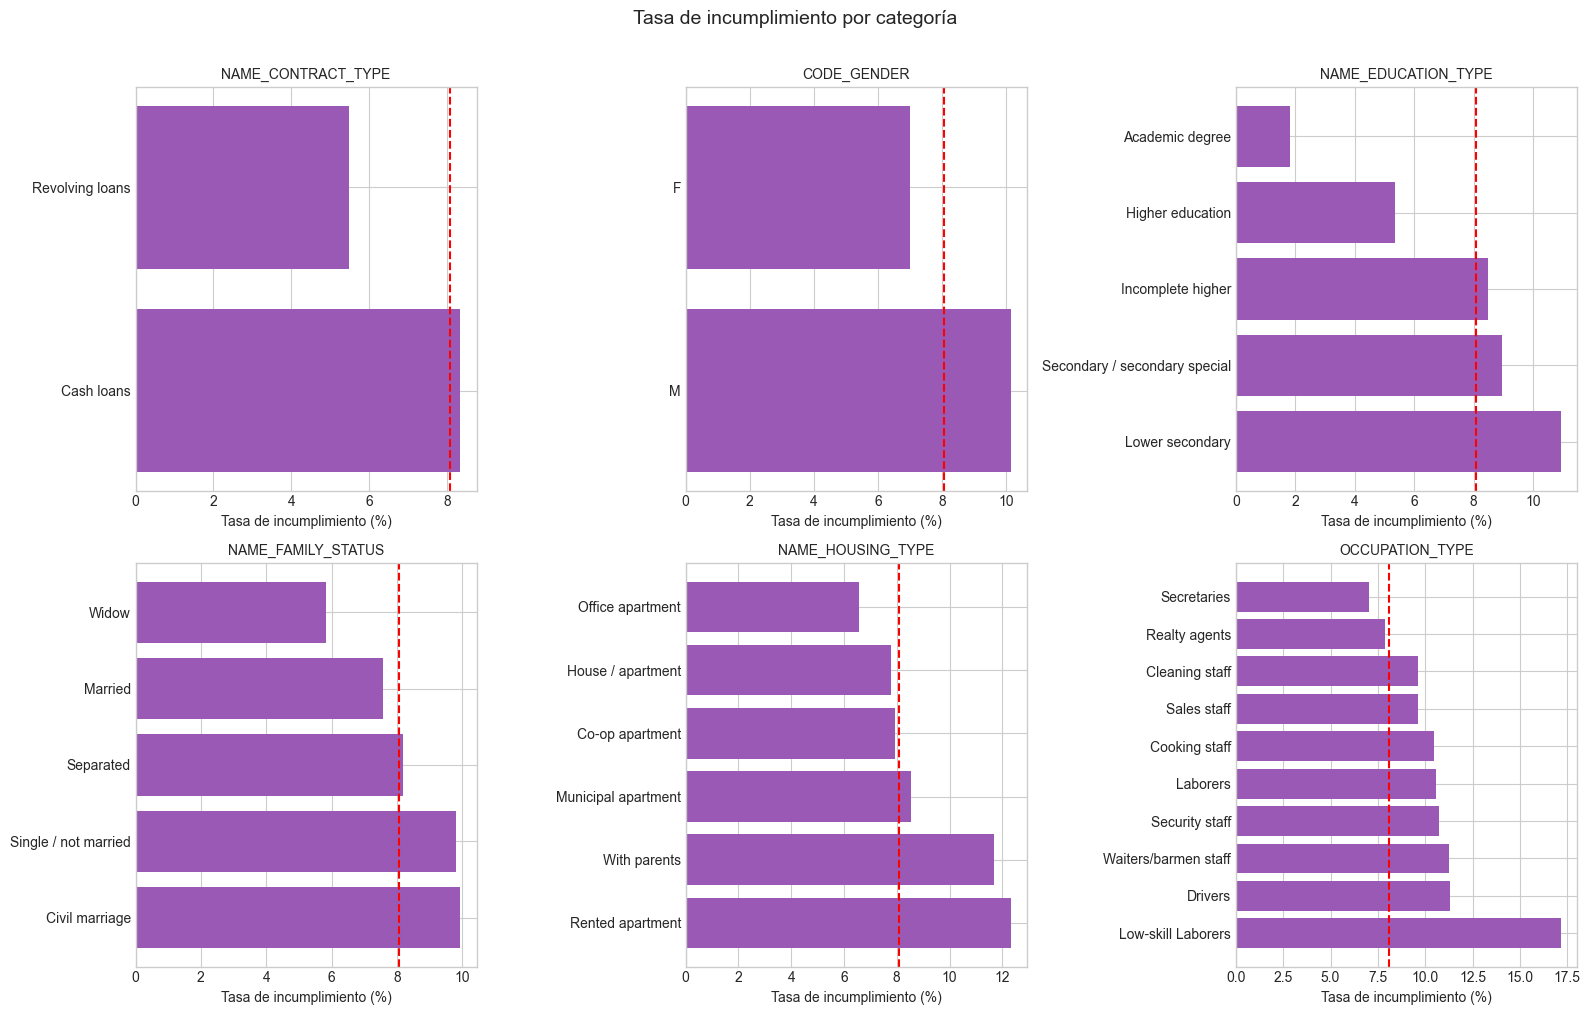

In [11]:
# Tasa de incumplimiento por categoría — las más informativas
def plot_cat_default_rate(col, ax, top_n=10):
    rate = df.groupby(col)['TARGET'].agg(['mean', 'count']).reset_index()
    rate.columns = [col, 'default_rate', 'count']
    rate = rate[rate['count'] > 100]  # mínimo 100 observaciones
    rate = rate.sort_values('default_rate', ascending=False).head(top_n)
    
    bars = ax.barh(rate[col], rate['default_rate'] * 100, color='#9b59b6')
    ax.set_xlabel('Tasa de incumplimiento (%)')
    ax.set_title(col, fontsize=10)
    ax.axvline(df['TARGET'].mean() * 100, color='red', linestyle='--', label='Promedio')

# Seleccionar las más interesantes manualmente
interesting_cats = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE',
                    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
interesting_cats = [c for c in interesting_cats if c in cat_cols]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(interesting_cats):
    plot_cat_default_rate(col, axes[i])

plt.suptitle('Tasa de incumplimiento por categoría', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Outliers en variables clave

Algunas columnas tienen valores negativos que representan días (ej. `DAYS_BIRTH` = días desde nacimiento, negativo). Esto es intencional en el dataset.

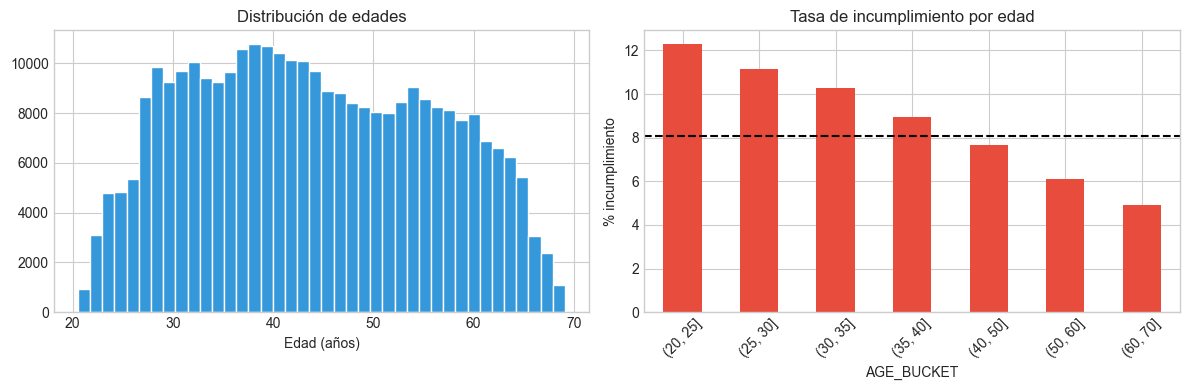

In [12]:
# DAYS_BIRTH: edad real del solicitante
df['AGE_YEARS'] = df['DAYS_BIRTH'].abs() / 365

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de edades
axes[0].hist(df['AGE_YEARS'], bins=40, color='#3498db', edgecolor='white')
axes[0].set_title('Distribución de edades')
axes[0].set_xlabel('Edad (años)')

# Tasa de incumplimiento por rango de edad
df['AGE_BUCKET'] = pd.cut(df['AGE_YEARS'], bins=[20, 25, 30, 35, 40, 50, 60, 70])
age_rate = df.groupby('AGE_BUCKET', observed=False)['TARGET'].mean() * 100
age_rate.plot(kind='bar', ax=axes[1], color='#e74c3c', rot=45)
axes[1].set_title('Tasa de incumplimiento por edad')
axes[1].set_ylabel('% incumplimiento')
axes[1].axhline(df['TARGET'].mean() * 100, color='black', linestyle='--')

plt.tight_layout()
plt.show()

# Limpiar columnas temporales
df.drop(columns=['AGE_YEARS', 'AGE_BUCKET'], inplace=True)

In [13]:
# DAYS_EMPLOYED: un valor 365243 es un placeholder para jubilados/desempleados
print('Valores de DAYS_EMPLOYED == 365243:', (df['DAYS_EMPLOYED'] == 365243).sum())
print('Tasa de incumplimiento en ese grupo:', 
      df[df['DAYS_EMPLOYED'] == 365243]['TARGET'].mean().round(3))
print('Tasa de incumplimiento en el resto:', 
      df[df['DAYS_EMPLOYED'] != 365243]['TARGET'].mean().round(3))

Valores de DAYS_EMPLOYED == 365243: 55374
Tasa de incumplimiento en ese grupo: 0.054
Tasa de incumplimiento en el resto: 0.087


## 7. Resumen ejecutivo del EDA

Completar con hallazgos al terminar de correr el notebook.

In [14]:
print('=== RESUMEN EDA ===')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
print(f'Tasa de incumplimiento: {df["TARGET"].mean()*100:.2f}%')
print(f'Columnas con missings: {df.isnull().any().sum()}')
print(f'Columnas con >40% missings: {(df.isnull().mean() > 0.4).sum()}')
print(f'Variables numéricas: {df.select_dtypes(include=np.number).shape[1]}')
print(f'Variables categóricas: {df.select_dtypes(include="object").shape[1]}')

=== RESUMEN EDA ===
Filas: 307,511 | Columnas: 122
Tasa de incumplimiento: 8.07%
Columnas con missings: 67
Columnas con >40% missings: 49
Variables numéricas: 106
Variables categóricas: 16
